In [16]:
!pip install scipy

# 2. Kiểm định giả thuyết

Kiểm định các giả thuyết nghiên cứu trên tập dữ liệu **Wine Quality Red**.

Mỗi cặp gồm **giả thuyết không (H)** và **giả thuyết đối (H')**. Nếu p-value < α thì **bác bỏ H'** và **chấp nhận H**.

**Mức ý nghĩa:** α = 0,05 cho tất cả kiểm định.

### Các giả thuyết nghiên cứu (H)

| Mã | Nội dung |
|----|----------|
| **H0** | Nồng độ cồn trung bình có thay đổi đáng kể theo điểm chất lượng chủ quan |
| **H1** | Rượu cồn cao hơn có xu hướng được đánh giá chất lượng tốt hơn |
| **H2** | Độ axit bay hơi cao ảnh hưởng tiêu cực đến chất lượng |

### Các giả thuyết đối (H')

| Mã | Nội dung |
|----|----------|
| **H'0** | Nồng độ cồn trung bình **không** thay đổi đáng kể theo điểm chất lượng |
| **H'1** | Hàm lượng cồn **không** có mối liên hệ tích cực đáng kể với chất lượng |
| **H'2** | Độ axit bay hơi **không** ảnh hưởng đáng kể đến chất lượng |

## 2.1. Phương pháp kiểm định

| Mã | H (nghiên cứu) | H' (đối / H₀) | Phương pháp | Điều kiện áp dụng | α |
|----|----------------|---------------|-------------|-------------------|---|
| **H0** | Alcohol khác biệt theo quality | Không khác biệt | **Kruskal-Wallis** (so sánh nhiều nhóm độc lập dựa trên thứ hạng) | Các quan sát độc lập; ≥ 2 nhóm theo `quality`; không yêu cầu phân phối chuẩn hay phương sai đồng nhất | 0,05 (hai phía) |
| **H1** | Cồn cao → quality tốt hơn | μ_cồn(nhóm cao) ≤ μ_cồn(nhóm thấp) | **t-test hai mẫu độc lập** (một phía); dự phòng **Wilcoxon rank-sum** | Gom nhóm: quality ≥ 6 (cao) vs ≤ 5 (thấp); chuẩn + phương sai đồng nhất | 0,05 (một phía) |
| **H2** | Axit bay hơi cao → quality thấp | μ_axit(nhóm cao) ≥ μ_axit(nhóm thấp) | **t-test hai mẫu độc lập** (một phía); dự phòng **Wilcoxon rank-sum** | Tương tự H1 | 0,05 (một phía) |

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from hypothesis_testing import hypothesis_test

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

ALPHA = 0.05
DATA_PATH = Path("dataset/winequality-red.csv")
df = pd.read_csv(DATA_PATH)

## 2.2. Kiểm định H0 / H'0 — Kruskal-Wallis

**Giả thuyết nghiên cứu (H0):** Nồng độ cồn trung bình không thay đổi đáng kể theo điểm chất lượng chủ quan.

**Giả thuyết đối (H'0):** Nồng độ cồn trung bình **có** thay đổi đáng kể theo điểm chất lượng.

**Phương pháp:** Kruskal-Wallis (phi tham số, so sánh nhiều nhóm độc lập dựa trên thứ hạng).

Trong đó: **H** là thống kê Kruskal-Wallis; **k** là số nhóm (số mức `quality`); bậc tự do **k − 1**.

**Bác bỏ H'0 khi và chỉ khi:**

$$H > \chi^2_{\alpha;\, k-1}$$

(tương đương **p-value < α**). Khi đó **chấp nhận H0**.

**Mức ý nghĩa:** α = 0,05.

,Số mẫu,Trung bình,Trung vị,Độ lệch chuẩn
quality,,,,
3,10,9.955000,9.925,0.818009
4,53,10.265094,10.000,0.934776
5,681,9.899706,9.700,0.736521
6,638,10.629519,10.500,1.049639
7,199,11.465913,11.500,0.961933
8,18,12.094444,12.150,1.224011


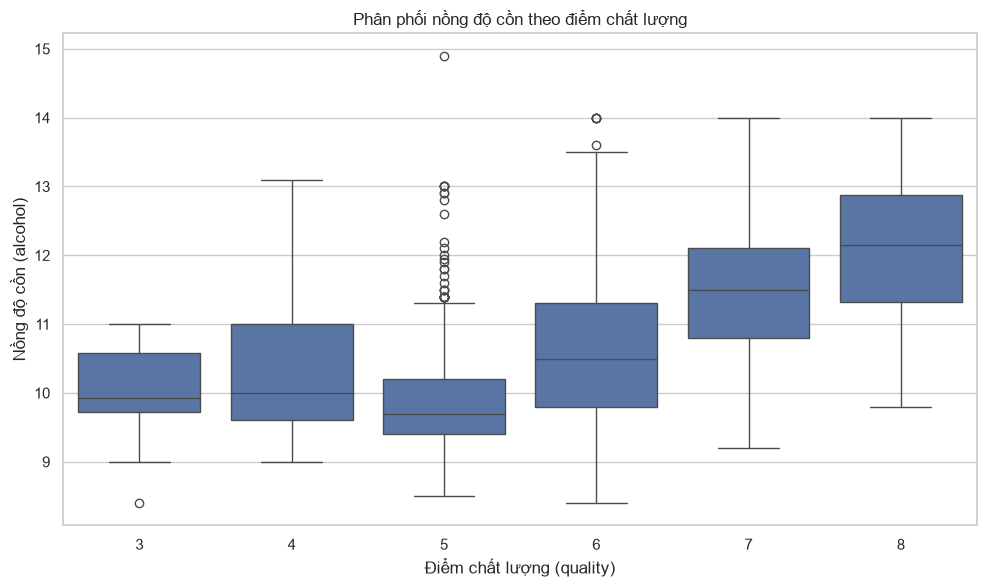

In [18]:
# Thống kê mô tả alcohol theo từng mức quality
alcohol_by_quality = (
    df.groupby("quality")["alcohol"]
    .agg(["count", "mean", "median", "std"])
    .rename(columns={
        "count": "Số mẫu",
        "mean": "Trung bình",
        "median": "Trung vị",
        "std": "Độ lệch chuẩn",
    })
)
display(alcohol_by_quality)

fig, ax = plt.subplots()
sns.boxplot(data=df, x="quality", y="alcohol", ax=ax)
ax.set_xlabel("Điểm chất lượng (quality)")
ax.set_ylabel("Nồng độ cồn (alcohol)")
ax.set_title("Phân phối nồng độ cồn theo điểm chất lượng")
plt.tight_layout()
plt.show()

In [32]:
# Kruskal-Wallis: so sánh alcohol giữa các nhóm quality
quality_levels = sorted(df["quality"].unique())
groups = [df.loc[df["quality"] == q, "alcohol"].values for q in quality_levels]

result_h0 = hypothesis_test(
    "kruskal_wallis", alternative="greater", groups=groups, alpha=ALPHA
)

H0 = "Nồng độ cồn trung bình không có thay đổi đáng kể theo điểm chất lượng chủ quan."
H0_prime = "Nồng độ cồn trung bình có thay đổi đáng kể theo điểm chất lượng."

print("=== Kiểm định Kruskal-Wallis: H0 / H'0 ===")
print(f"Số nhóm k = {result_h0['k']} (quality: {quality_levels})")
print(f"Bậc tự do k - 1 = {result_h0['df']}")
print(f"Thống kê {result_h0['statistic_name']} = {result_h0['statistic']:.4f}")
print(
    f"Giá trị tới hạn χ²_{{α; k-1}} = χ²_{{{ALPHA}; {result_h0['df']}}} "
    f"= {result_h0['critical_value']:.4f}"
)
print(f"p-value = {result_h0['p_value']:.6f}")
print(f"Mức ý nghĩa α = {ALPHA}")

reject = result_h0["p_value"] < ALPHA
print(
    f"\nH > χ²_{{α; k-1}} ?  {result_h0['statistic']:.4f} > "
    f"{result_h0['critical_value']:.4f} → {result_h0['statistic'] > result_h0['critical_value']}"
)

if reject:
    print("\nKết luận: Bác bỏ H0, chấp nhận H'0.")
    print(f"→ {H0_prime}")
else:
    print("\nKết luận: Không bác bỏ H0.")
    print(f"→ {H0}")

=== Kiểm định Kruskal-Wallis: H0 / H'0 ===
Số nhóm k = 6 (quality: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)])
Bậc tự do k - 1 = 5
Thống kê H = 412.3768
Giá trị tới hạn χ²_{α; k-1} = χ²_{0.05; 5} = 11.0705
p-value = 0.000000
Mức ý nghĩa α = 0.05

H > χ²_{α; k-1} ?  412.3768 > 11.0705 → True

Kết luận: Bác bỏ H0, chấp nhận H'0.
→ Nồng độ cồn trung bình có thay đổi đáng kể theo điểm chất lượng.


## 2.3. Kiểm định H1 / H'1 — t-test hai mẫu độc lập (một phía)

**Giả thuyết nghiên cứu (H1):** Rượu cồn cao hơn có xu hướng được đánh giá chất lượng tốt hơn.

**Giả thuyết đối (H'1):** Hàm lượng cồn **không** có mối liên hệ tích cực đáng kể với chất lượng.

**Phương pháp:** t-test hai mẫu độc lập (một phía); dự phòng Wilcoxon rank-sum.

Gom nhóm: quality ≥ 6 (cao) vs quality ≤ 5 (thấp).

**Mức ý nghĩa:** α = 0,05.

In [34]:
# Gom nhóm quality cao / thấp
high_q = df[df["quality"] >= 6]["alcohol"]
low_q = df[df["quality"] <= 5]["alcohol"]

H1 = "Rượu cồn cao hơn có xu hướng được đánh giá chất lượng tốt hơn."
H1_prime = "Hàm lượng cồn không có mối liên hệ tích cực đáng kể với chất lượng."

print(f"Nhóm quality cao (≥6): n = {len(high_q)}, trung bình = {high_q.mean():.4f}")
print(f"Nhóm quality thấp (≤5): n = {len(low_q)}, trung bình = {low_q.mean():.4f}")

# t-test hai mẫu độc lập (một phía: μ_cao > μ_thấp)
result_h1_t = hypothesis_test(
    "t_two_means_independent",
    x1=high_q.mean(),
    x2=low_q.mean(),
    s1=high_q.std(ddof=1),
    s2=low_q.std(ddof=1),
    n1=len(high_q),
    n2=len(low_q),
    alpha=ALPHA,
    alternative="greater",
)

print("\n=== Kiểm định t hai mẫu độc lập: H1 / H'1 ===")
print(f"Thống kê {result_h1_t['statistic_name']} = {result_h1_t['statistic']:.4f}")
print(f"Giá trị tới hạn = {result_h1_t['critical_value']:.4f}")
print(f"p-value = {result_h1_t['p_value']:.6f}")
print(f"Mức ý nghĩa α = {ALPHA}")

reject = result_h1_t["p_value"] < ALPHA
print(f"\nBác bỏ H'1 ? → {reject}")

# Dự phòng phi tham số: Wilcoxon rank-sum
result_h1_w = hypothesis_test(
    "wilcoxon_rank_sum",
    sample1=high_q.values,
    sample2=low_q.values,
    alpha=ALPHA,
    alternative="greater",
)

print("\n=== Dự phòng Wilcoxon rank-sum ===")
print(f"Thống kê {result_h1_w['statistic_name']} = {result_h1_w['statistic']:.4f}")
print(f"p-value = {result_h1_w['p_value']:.6f}")
print(f"Bác bỏ H'1 ? → {result_h1_w['p_value'] < ALPHA}")

if reject:
    print("\nKết luận: Bác bỏ H'1, chấp nhận H1.")
    print(f"→ {H1}")
else:
    print("\nKết luận: Không bác bỏ H'1.")
    print(f"→ {H1_prime}")

Nhóm quality cao (≥6): n = 855, trung bình = 10.8550
Nhóm quality thấp (≤5): n = 744, trung bình = 9.9265

=== Kiểm định t hai mẫu độc lập: H1 / H'1 ===
Thống kê T = 19.2923
Giá trị tới hạn = 1.6458
p-value = 0.000000
Mức ý nghĩa α = 0.05

Bác bỏ H'1 ? → True

=== Dự phòng Wilcoxon rank-sum ===
Thống kê U = 481313.0000
p-value = 0.000000
Bác bỏ H'1 ? → True

Kết luận: Bác bỏ H'1, chấp nhận H1.
→ Rượu cồn cao hơn có xu hướng được đánh giá chất lượng tốt hơn.


## 2.4. Kiểm định H2 / H'2 — t-test hai mẫu độc lập (một phía)

**Giả thuyết nghiên cứu (H2):** Độ axit bay hơi cao ảnh hưởng tiêu cực đến chất lượng.

**Giả thuyết đối (H'2):** Độ axit bay hơi **không** ảnh hưởng đáng kể đến chất lượng.

**Phương pháp:** t-test hai mẫu độc lập (một phía); dự phòng Wilcoxon rank-sum.

Gom nhóm: quality ≥ 6 (cao) vs quality ≤ 5 (thấp).

**Mức ý nghĩa:** α = 0,05.

In [21]:
# Gom nhóm quality cao / thấp — biến volatile acidity
high_va = df[df["quality"] >= 6]["volatile acidity"]
low_va = df[df["quality"] <= 5]["volatile acidity"]

H2 = "Độ axit bay hơi cao ảnh hưởng tiêu cực đến chất lượng."
H2_prime = "Độ axit bay hơi không ảnh hưởng đáng kể đến chất lượng."

print(f"Nhóm quality cao (≥6): n = {len(high_va)}, trung bình VA = {high_va.mean():.4f}")
print(f"Nhóm quality thấp (≤5): n = {len(low_va)}, trung bình VA = {low_va.mean():.4f}")

# t-test một phía: μ_axit(cao) < μ_axit(thấp)  ⟺  alternative="less"
result_h2_t = hypothesis_test(
    "t_two_means_independent",
    x1=high_va.mean(),
    x2=low_va.mean(),
    s1=high_va.std(ddof=1),
    s2=low_va.std(ddof=1),
    n1=len(high_va),
    n2=len(low_va),
    alpha=ALPHA,
    alternative="less",
)

print("\n=== Kiểm định t hai mẫu độc lập: H2 / H'2 ===")
print(f"Thống kê {result_h2_t['statistic_name']} = {result_h2_t['statistic']:.4f}")
print(f"Giá trị tới hạn = {result_h2_t['critical_value']:.4f}")
print(f"p-value = {result_h2_t['p_value']:.6f}")
print(f"Mức ý nghĩa α = {ALPHA}")

reject = result_h2_t["p_value"] < ALPHA
print(f"\nBác bỏ H'2 ? → {reject}")

# Dự phòng phi tham số: Wilcoxon rank-sum
result_h2_w = hypothesis_test(
    "wilcoxon_rank_sum",
    sample1=high_va.values,
    sample2=low_va.values,
    alpha=ALPHA,
    alternative="less",
)

print("\n=== Dự phòng Wilcoxon rank-sum ===")
print(f"Thống kê {result_h2_w['statistic_name']} = {result_h2_w['statistic']:.4f}")
print(f"p-value = {result_h2_w['p_value']:.6f}")
print(f"Bác bỏ H'2 ? → {result_h2_w['p_value'] < ALPHA}")

if reject:
    print("\nKết luận: Bác bỏ H'2, chấp nhận H2.")
    print(f"→ {H2}")
else:
    print("\nKết luận: Không bác bỏ H'2.")
    print(f"→ {H2_prime}")

Nhóm quality cao (≥6): n = 855, trung bình VA = 0.4741
Nhóm quality thấp (≤5): n = 744, trung bình VA = 0.5895

=== Kiểm định t hai mẫu độc lập: H2 / H'2 ===
Thống kê T = -13.5655
Giá trị tới hạn = -1.6458
p-value = 0.000000
Bác bỏ H'2 ? → True

=== Dự phòng Wilcoxon rank-sum ===
Thống kê U = 197208.0000
p-value = 0.000000
Bác bỏ H'2 ? → False

Kết luận: Bác bỏ H'2, chấp nhận H2.
→ Nhóm quality thấp có độ axit bay hơi trung bình cao hơn đáng kể so với nhóm quality cao.
